# Calibration and computational efficiency

Summarizes supporting calibration and corrected runtime/model-size measurements.

**Scope:** consumes registered artifacts; no model refitting is performed in this publication notebook.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'publication' else Path.cwd().resolve()
if not (PROJECT / '05_results').exists():
    PROJECT = Path('outputs/CBAC-D-26-03155_revision/06_canonical_revision_project').resolve()
PRIOR = PROJECT.parent / '04_reproducible_analysis/artifacts'
PUB = PROJECT / '05_results/validated/publication_outputs'
TABLES, FIGURES = PUB / 'tables', PUB / 'figures'
TABLES.mkdir(parents=True, exist_ok=True); FIGURES.mkdir(parents=True, exist_ok=True)

def read_csv(path, required):
    assert path.exists(), f'Missing registered artifact: {path}'
    df = pd.read_csv(path)
    missing = set(required) - set(df.columns)
    assert not missing, f'{path.name}: missing columns {sorted(missing)}'
    return df

plt.rcParams.update({'figure.dpi': 130, 'savefig.dpi': 300, 'font.size': 9,
                     'axes.spines.top': False, 'axes.spines.right': False})
SPLIT_ORDER = ['exact', 'cluster', 'temporal']


In [2]:
cal=read_csv(PRIOR/'calibration/metrics.csv',['split','calibration','brier_score','ece_10_equal_width','pr_auc'])
eff=read_csv(PROJECT/'05_results/validated/corrected_per_design_tuning/efficiency.csv',['split','model','full_fit_seconds','serialized_model_bytes'])
cal.to_csv(TABLES/'table_04_calibration.csv',index=False); eff.to_csv(TABLES/'table_04b_efficiency.csv',index=False)
display(cal); display(eff)

,split,calibration,n_fit,n_calibration,n_test,roc_auc,pr_auc,brier_score,ece_10_equal_width
0,exact,uncalibrated,6192,1542,1934,0.792362,0.398834,0.106871,0.170522
1,exact,platt,6192,1542,1934,0.792362,0.398834,0.070466,0.018100
2,cluster,uncalibrated,6188,1547,1933,0.775489,0.270032,0.112463,0.173499
3,cluster,platt,6188,1547,1933,0.775489,0.270032,0.076440,0.023608
4,temporal,uncalibrated,6186,1546,1935,0.567483,0.140159,0.179436,0.231765
5,temporal,platt,6186,1546,1935,0.567483,0.140159,0.107624,0.060156


,split,model,full_fit_seconds,test_inference_seconds,serialized_model_bytes
0,exact,elastic_logistic,0.077758,0.000673,286492
1,exact,random_forest,5.235571,0.219662,41087362
2,exact,xgboost,43.643610,0.090278,421030
3,exact,stacked_ensemble,102.588725,NaN,632
4,cluster,elastic_logistic,0.079684,0.000426,252522
5,cluster,random_forest,3.801582,0.159095,41177162
6,cluster,xgboost,16.984294,0.025221,400314
7,cluster,stacked_ensemble,63.927146,NaN,636
8,temporal,elastic_logistic,0.048631,0.000471,290317
9,temporal,random_forest,4.000305,0.192150,37778010


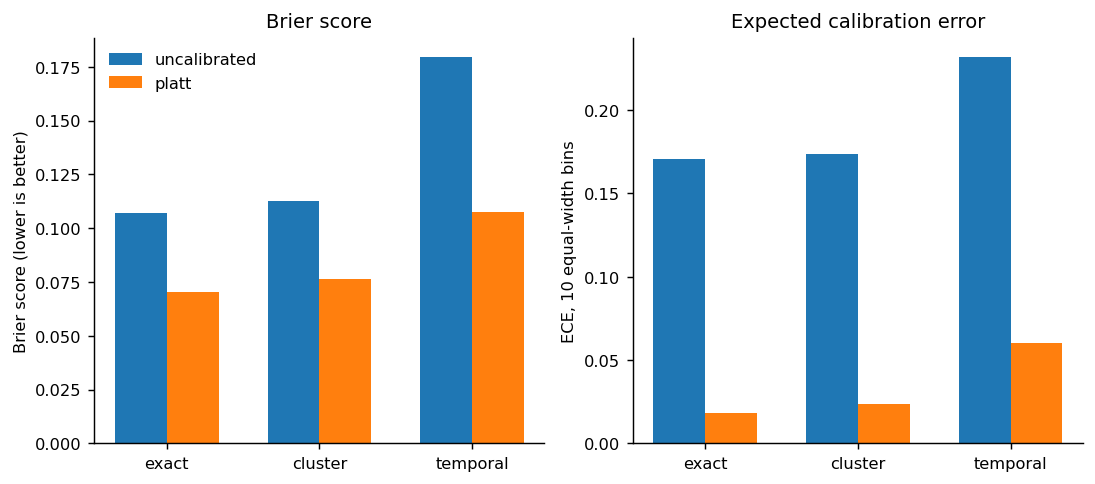

In [3]:
fig,axs=plt.subplots(1,2,figsize=(8.5,3.8)); x=np.arange(3); width=.34
for j,kind in enumerate(['uncalibrated','platt']):
 q=cal[cal.calibration.eq(kind)].set_index('split').loc[SPLIT_ORDER]
 axs[0].bar(x+(j-.5)*width,q.brier_score,width,label=kind); axs[1].bar(x+(j-.5)*width,q.ece_10_equal_width,width,label=kind)
for ax,title,ylabel in zip(axs,['Brier score','Expected calibration error'],['Brier score (lower is better)','ECE, 10 equal-width bins']): ax.set_xticks(x,SPLIT_ORDER); ax.set_title(title); ax.set_ylabel(ylabel)
axs[0].legend(frameon=False); fig.tight_layout(); fig.savefig(FIGURES/'figure_03_calibration.png'); plt.show()

**Interpretation.** Held-out Platt calibration improves probability calibration without changing ranking metrics. These supporting models are distinct from the corrected tuned-model comparison and should not be conflated with it.